# ⚔️ Algorithm Wars
### 8 classic ML models fight for your data — across 3 deliberately different datasets

|Item|Detail|
|---|---|
| **Goal** | Build intuition about *when* each algorithm wins, not just *which* scores highest |
| **Datasets** | Breast Cancer (small, numeric) · Adult Income (large, mixed types) · BBC News (text, high-dimensional) |
| **Stack** | scikit-learn, XGBoost, pandas, matplotlib, seaborn |

---

## Imports & Setup

In [1]:
from visualize import plot_test_accuracy, plot_accuracy_vs_fit_time, plot_decision_boundaries
from data_loaders import get_data1, get_data2, get_data3
from harness import compare_models
import random
import numpy as np

random.seed(37)
np.random.seed(37)

c:\Users\Kushagra\AppData\Local\Programs\Python\Python313\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


---
## Dataset A — Breast Cancer Wisconsin
**569 samples · 30 numeric features · binary classification**

Small, clean, all-numeric, and low-dimensional.

### A — Results

In [2]:
X, y, numerical_columns, categorical_columns, data_type = get_data1()
cancer_results = compare_models(X, y, numerical_columns, categorical_columns, data_type, scoring = 'accuracy', cv_folds = 5)

display(cancer_results[["model", "mean_train_score", "mean_test_score", "mean_fit_time"]]
    .rename(columns={
        "model": "Model",
        "mean_train_score": "Train Accuracy",
        "mean_test_score": "Test Accuracy",
        "mean_fit_time": "Mean Fit Time (s)"
    })
    .style.format({
        "Train Accuracy": "{:.2f}",
        "Test Accuracy": "{:.2f}",
        "Mean Fit Time (s)": "{:.3f}"
    })
)

,Model,Train Accuracy,Test Accuracy,Mean Fit Time (s)
0,Logistic Regression,98.90,98.07,0.026
1,SVM (RBF),98.77,97.71,0.017
2,SVM (Linear),99.08,96.84,0.015
3,XGBoost,100.00,96.48,0.122
4,K-Nearest Neighbors,97.72,96.31,0.009
5,Gradient Boosting,100.00,96.31,0.537
6,Random Forest,100.00,95.60,0.252
7,Decision Tree,100.00,93.15,0.031
8,Gaussian Naive Bayes,93.80,92.80,0.012


### A — Visualizations

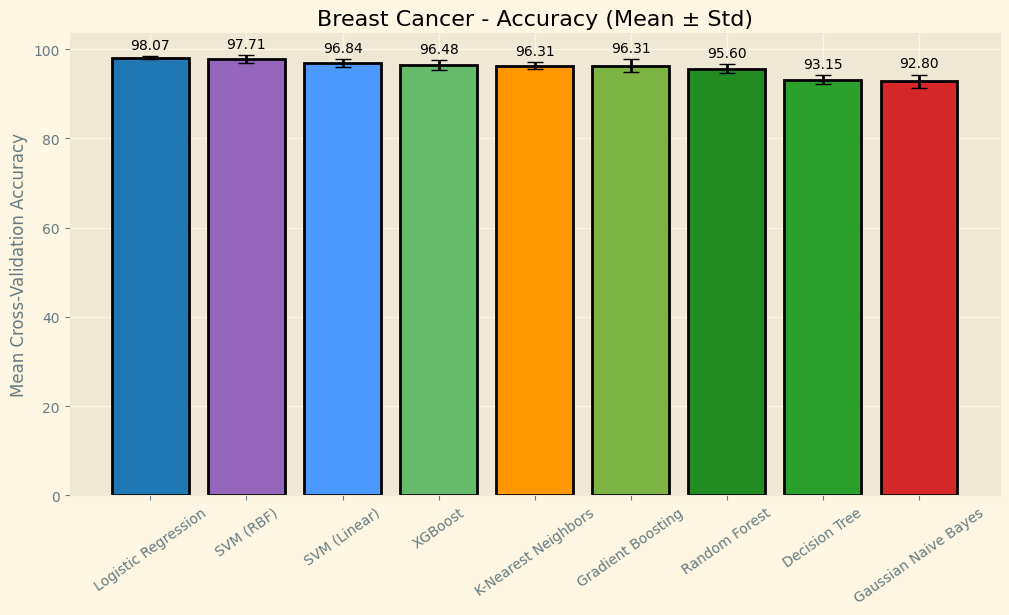

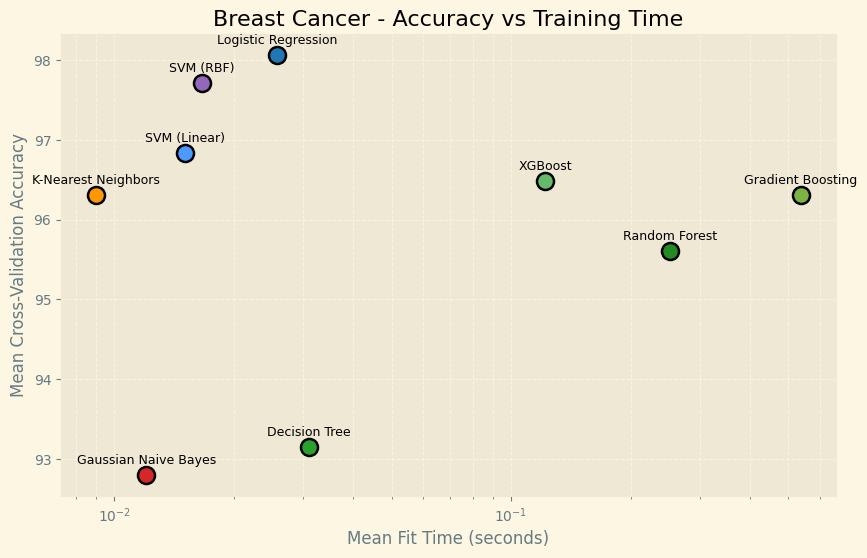

In [3]:
plot_test_accuracy(cancer_results, "Breast Cancer")
plot_accuracy_vs_fit_time(cancer_results, "Breast Cancer")

### A — Decision Boundaries

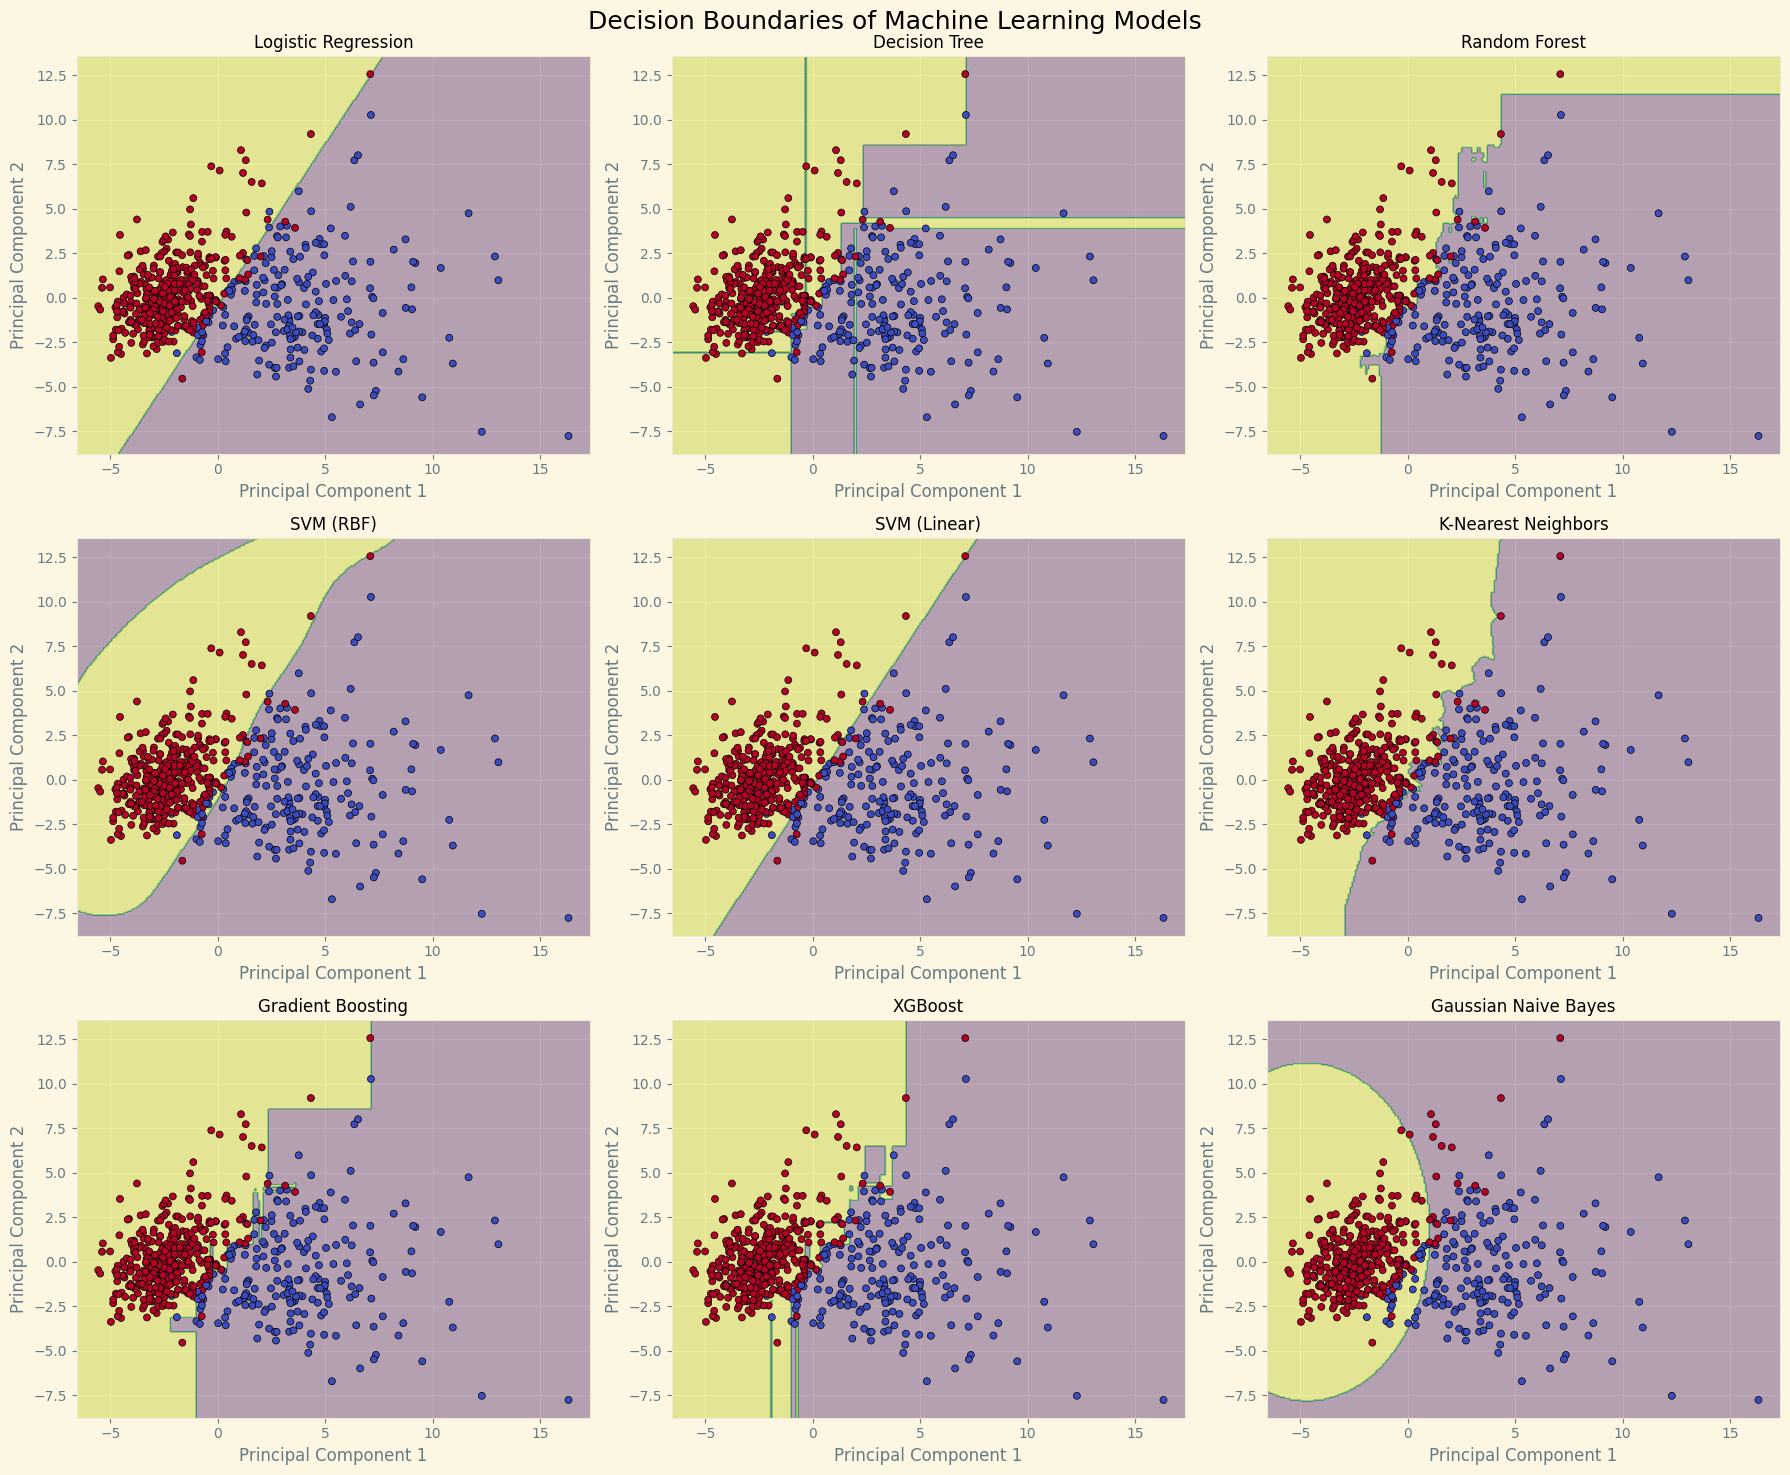

In [4]:
plot_decision_boundaries(X, y, numerical_columns, categorical_columns, preprocessor_type="tabular")

### A — Observations

I thought that on a small, non-linear dataset, KNN, and tree-based algorithms like random forest and decision tress would be the best performers. But in practice, linear models (LR, SVM(RBF)) came out on top, which seems completely counterintuitive to me.


Q: *Which model won? Why does that make sense for this dataset?*
> The linear models took the victory, which seems completely counterintuitive to me. Given the dataset is categorized as non-linear, it doesn't make sense to me

Q: *Look at the train vs test accuracy gap for Decision Tree — what does that tell you?*
> Perfect training accuracy versus a mediocre test accuracy. Similar pattern can be observed for all tree based models. This tells us that there is a variance problem with these models, ie, they are overfitting on the training entries, making them unsuitable for datasets of this category

Q: *Is the difference between #1 and #2 larger than the std? Or are they effectively tied?*
> The difference between the means is merely 0.36%, which by itself can be considered negligible. But when we take into account the standard deviation of the two (negligible for #1 but high for #2), these models can be considered tied

Q: *What do the decision boundary shapes tell you about each algorithm's assumptions?*
> - LR, SVM(Linear) : One line dividing the regions
> - DT, XGB, GB: multiple rectangles dividing the regions into 2
> - SVM(RBF), NB, KNN, RF: jagged lines / big curves


---
## Dataset B — Adult Census Income
**~48,000 samples · mix of numeric and categorical features · binary classification**

Much larger, mixed types

### B — Results

In [5]:
X, y, numerical_columns, categorical_columns, data_type = get_data2()
adult_results = compare_models(X, y, numerical_columns, categorical_columns, data_type, scoring = 'accuracy', cv_folds = 5)

display(adult_results[["model", "mean_train_score", "mean_test_score", "mean_fit_time"]]
    .rename(columns={
        "model": "Model",
        "mean_train_score": "Train Accuracy",
        "mean_test_score": "Test Accuracy",
        "mean_fit_time": "Mean Fit Time (s)"
    })
    .style.format({
        "Train Accuracy": "{:.2f}",
        "Test Accuracy": "{:.2f}",
        "Mean Fit Time (s)": "{:.3f}"
    })
)

,Model,Train Accuracy,Test Accuracy,Mean Fit Time (s)
0,XGBoost,89.59,87.23,1.218
1,Gradient Boosting,86.90,86.65,22.732
2,SVM (RBF),86.50,85.55,144.709
3,Random Forest,99.99,85.31,8.182
4,SVM (Linear),85.28,85.09,1.436
5,Logistic Regression,85.23,85.08,1.279
6,K-Nearest Neighbors,88.23,83.29,0.217
7,Decision Tree,99.99,81.61,1.202
8,Gaussian Naive Bayes,60.71,60.68,0.339


### B — Visualizations

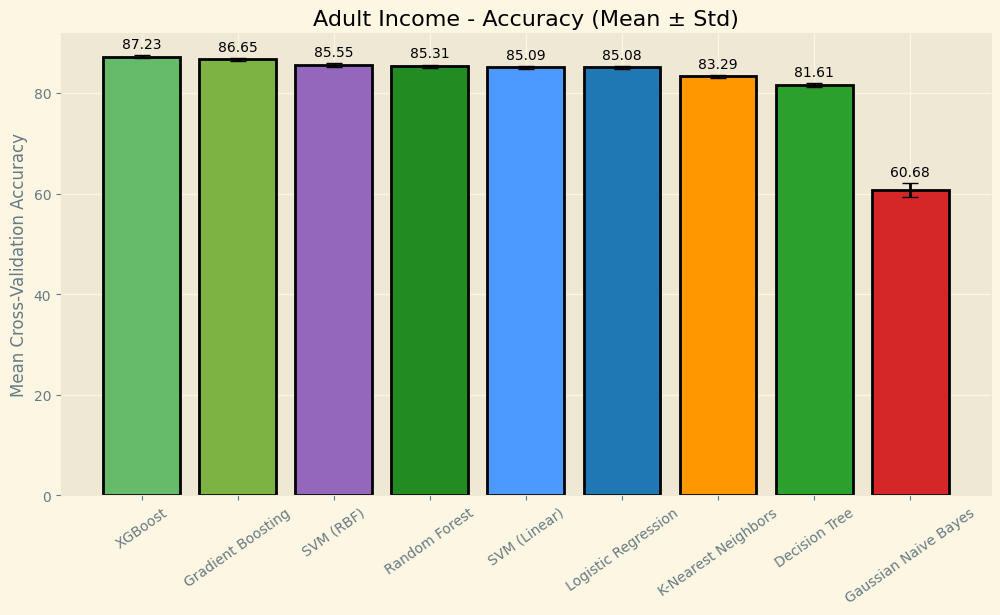

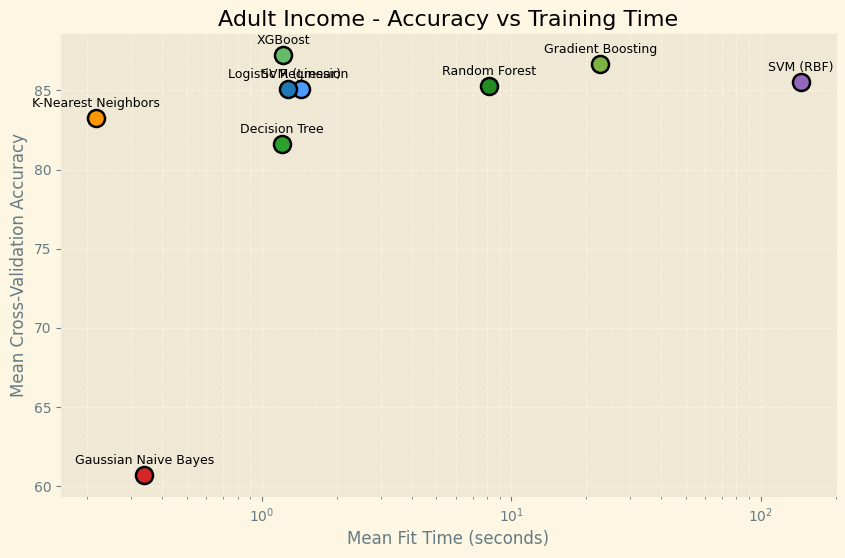

In [6]:
plot_test_accuracy(adult_results, "Adult Income")
plot_accuracy_vs_fit_time(adult_results, "Adult Income")

### B — Observations

I imagine that on a non-linear dataset with almost 50k entries along with both numerical and categorical features, the chances of linear models winning are dim. Given how forest based models tend to perform well on large datasets, I am putting my money on those, with decision tree not doing as well as the others

Q: *Did the rankings change from Dataset A? Which models moved the most?*
> My prediction was right. Contrary to dataset A, linear models lagged in the rankings, while the optimized tree-based models triumphed. Also, decision tree turned out to perform worse than the linear models. The biggest change in ranking is LR, dropping from #1 to #6

Q: *Compare SVM (RBF)'s fit_time here vs Dataset A. What happened and why?*
> The fit time went up WAY too much. Hundreds of seconds taken per run to fit while other models take a fraction of that, and for results that are not even worth the tradeoff. This is because of the polynomial training time complexity of SVM. Thus, SVMs do no work well on larger datasets

Q: *Did tree-based methods (RF, GB, XGBoost) take over as expected?*
> Yes, because of the large and mixed-feature dataset

Q: *Which model gives the best accuracy-per-second tradeoff?*
> KNN lags the winning algorithm, XGBoost, by 4% in accuracy, but it takes 7X less time to get to that result. So if you prioritise time over slightly lower accuracy, KNN would be the way to go


---
## Dataset C — BBC News (Text Classification)
**2,225 articles · 5 categories · TF-IDF features (high-dimensional, sparse)**

TF-IDF vectorization creates thousands of sparse features

### C — Results

In [7]:
X, y, numerical_columns, categorical_columns, data_type = get_data3()
bbc_results = compare_models(X, y, numerical_columns, categorical_columns, data_type, scoring = 'accuracy', cv_folds = 5)

display(bbc_results[["model", "mean_test_score", "mean_fit_time"]]
    .rename(columns={
        "model": "Model",
        "mean_test_score": "Test Accuracy",
        "mean_fit_time": "Mean Fit Time (s)"
    })
    .style.format({
        "Test Accuracy": "{:.2f}",
        "Mean Fit Time (s)": "{:.3f}"
    })
)

'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/SetFit/bbc-news/resolve/9c31f7087a8c225be8b4c420d70216ef1f121eb0/bbc-news.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since SetFit/bbc-news couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\Kushagra\.cache\huggingface\datasets\SetFit___bbc-news\default\0.0.0\9c31f7087a8c225be8b4c420d70216ef1f121eb0 (last modified on Thu Jul 16 05:20:34 2026).


,Model,Test Accuracy,Mean Fit Time (s)
0,SVM (Linear),98.47,2.366
1,SVM (RBF),98.16,10.600
2,Logistic Regression,98.11,2.737
3,Multinomial Naive Bayes,97.30,4.247
4,K-Nearest Neighbors,96.40,2.240
5,Random Forest,96.13,4.180
6,Gradient Boosting,95.87,72.166
7,XGBoost,94.97,70.228
8,Decision Tree,83.60,3.082


### C — Visualizations

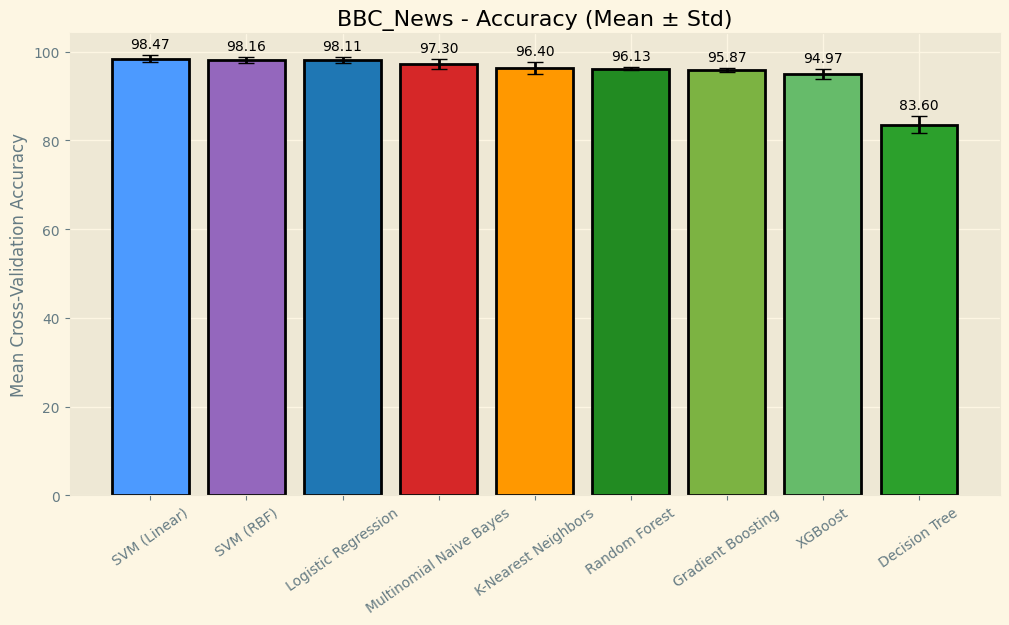

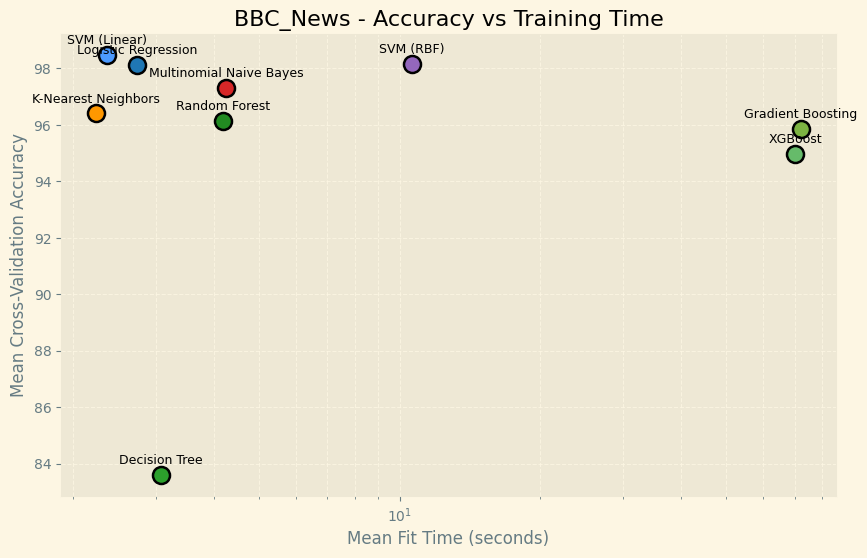

In [8]:
plot_test_accuracy(bbc_results, "BBC_News")
plot_accuracy_vs_fit_time(bbc_results, "BBC_News")

### C — Observations

The sparse features are all numerical, so linear models should do well, but I think so should tree models. I am not sure which one will be the victor.

Q: *Did linear models (LR, Linear SVM) take over on sparse text data?*
> Yes, linear and probabillistic functions won in terms of both accuracy and time taken. tree based models lost completely, especially the boosted algorithms

Q: *How did Multinomial Naive Bayes perform despite its "wrong" independence assumption?*
> it came forward as a very competitive algorithm. The assumption didn't matter since the word features that were the most relevent didnt reallt depend on the assumption, taking the consiquences of a bad assumption out of the equation

Q: *What happened to KNN? Why? (curse of dimensionality)*
> No, the curse of dimensionality did not take place here. This is because of the distinct features and categories that his dataset provided

Q: *Did tree-based methods struggle compared to their performance on tabular data? Why?*
> Yes, tree-based models had worst rankings and horrible fit times, Manly because of the fact that they split based on on feature. These splits not only created higher time demands, but also decreased the importance of features.

---
## Cross-Dataset Synthesis
### Rankings across all 3 datasets

| Model | Cancer (569) | Adult (48k) | BBC Text | Most notable |
|---|---|---|---|---|
| Logistic Regression | #1 | #6 | #3 | Never collapses — most consistent |
| SVM (RBF) | #2 | #3 | #2 | Stable in rank, unstable in time (0.018s → 145s) |
| SVM (Linear) | #3 | #5 | #1 | Best on text, average elsewhere |
| XGBoost | #4 | #1 | #8 | Biggest swing — best on tabular, worst on text |
| KNN | #5 | #7 | #5 | Middling everywhere |
| Gradient Boosting | #6 | #2 | #7 | Strong on large tabular, slow everywhere |
| Random Forest | #7 | #4 | #6 | Moderate, never leads |
| Decision Tree | #8 | #8 | #9 | Consistently worst — never use alone |
| Naive Bayes | #9 (Gaussian) | #9 (Gaussian) | #4 (Multinomial) | Dataset-type dependent: dead last twice, competitive on text |

### When to use what — my decision framework

*Write this in your own words based on what you actually observed, not what someone told you. Template:*

- *n < 10,000, all numeric  -> LR / SVM(RBF)*
- *n large, mixed types, tabular -> XGBoost*
- *High-dimensional sparse (text) -> LR / SVM(Linear)*
- *Need interpretability -> LR*
- *Need a 30-second baseline -> LR / Naive Bayes(only on text)*
- *Almost never -> Decision Tree*
- *Need one algorithm for versatile performance irrespective of time -> SVM(RBF)* 